In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Standard imports
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import tqdm as tqdm

# Special for plotting
from matplotlib.colors import LinearSegmentedColormap

In [3]:
# Import OpenSense modules as submodules
import sys
import os

sys.path.append(os.path.abspath("./pycomlink/"))
sys.path.append(os.path.abspath("./poligrain/src/"))
sys.path.append(os.path.abspath("./mergeplg/src/"))

import pycomlink as pycml 
import poligrain as plg
import mergeplg

/home/erlend/git/radar_adjustment_intercomparison/pycomlink/pycomlink/io/examples.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [4]:
# For advection decomposition
from pysteps.motion.lucaskanade import dense_lucaskanade

Pysteps configuration file found at: /home/erlend/miniforge3/envs/radar_adjustment_intercomparison/lib/python3.12/site-packages/pysteps/pystepsrc



# OpenRainER

In [5]:
# OpenRainER
ds_gauges = xr.open_dataset("data/covi_2024_OpenRainER/AWS_rainfall.nc")
ds_rad = xr.open_dataset("data/covi_2024_OpenRainER/openrainer_radar.nc")
ds_cmls = xr.open_dataset("data/processed_cml_OpenRainER.nc") 
rad_along = xr.open_dataset('data/covi_2024_OpenRainER/RADadj_along_cml.nc')

# Resample to 15 min resolution
ds_cmls = ds_cmls.R_acc.resample(time = '15min', label='right', closed='right').sum(skipna=True)
ds_cmls = ds_cmls.reduce(np.nanmean, dim='sublink_id')

In [6]:
ds_cmls = ds_cmls.to_dataset()

In [7]:
ds_cmls = ds_cmls.rename({'R_acc': 'rainfall_amount'})

In [8]:
ds_gauges = ds_gauges.rename({'latitude':'lat', 'longitude':'lon'})

In [9]:
ds_rad = ds_rad.rename({'lon':'x', 'lat':'y'})
ds_rad = ds_rad.rename({'lon_grid':'lon', 'lat_grid':'lat'})


In [10]:
rad_along = rad_along.sel(cml_id = ds_cmls.cml_id)
rad_along['rainfall_amount'] = rad_along['rainfall_amount'].transpose("cml_id", "time").reset_coords(drop=True)
ds_cmls['rainfall_radar'] = rad_along['rainfall_amount']

In [11]:
# Threshold lower values
radar_zero = 0.01  # here in sum mm over 15 minutes
ds_rad["rainfall_amount"] = xr.where(
    ds_rad.rainfall_amount > radar_zero, ds_rad.rainfall_amount, 0
)

In [12]:
ref_str = "EPSG:32632"

# Project OpenRainER data
ds_gauges.coords["x"], ds_gauges.coords["y"] = plg.spatial.project_point_coordinates(
    ds_gauges.lon, ds_gauges.lat, ref_str
)

(
    ds_cmls.coords["site_0_x"],
    ds_cmls.coords["site_0_y"],
) = plg.spatial.project_point_coordinates(
    ds_cmls.site_0_lon, ds_cmls.site_0_lat, ref_str
)
(
    ds_cmls.coords["site_1_x"],
    ds_cmls.coords["site_1_y"],
) = plg.spatial.project_point_coordinates(
    ds_cmls.site_1_lon, ds_cmls.site_1_lat, ref_str
)

# Midpoint
ds_cmls.coords["x"] = (ds_cmls.site_0_x + ds_cmls.site_1_x) / 2
ds_cmls.coords["y"] = (ds_cmls.site_0_y + ds_cmls.site_1_y) / 2

# Projected radar coords
ds_rad.coords["x_grid"], ds_rad.coords["y_grid"] = plg.spatial.project_point_coordinates( 
    ds_rad.lon, ds_rad.lat, ref_str
)


(array([ 3.,  0.,  0.,  1.,  0.,  0.,  1., 22., 73., 32.]),
 array([0.        , 0.08979553, 0.17959106, 0.26938659, 0.35918211,
        0.44897764, 0.53877317, 0.6285687 , 0.71836423, 0.80815976,
        0.89795529]),
 <BarContainer object of 10 artists>)

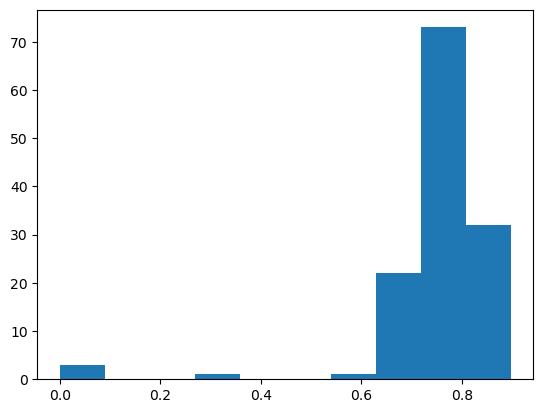

In [13]:
# MCC filter
from sklearn.metrics import matthews_corrcoef
mcc = np.zeros([ds_cmls.cml_id.size])
rainfall_amount = ds_cmls.rainfall_amount.data > 0.01
rainfall_radar = ds_cmls.rainfall_radar.data > 0.01

for i in range(ds_cmls.cml_id.size):
    cml = rainfall_amount[i, :]
    rad = rainfall_radar[i, :]
    mcc[i] = matthews_corrcoef(rad, cml)
keep = np.where(mcc > 0.2)[0]
ds_cmls = ds_cmls.isel(cml_id = keep)
ds_cmls
plt.hist(mcc)

In [14]:
# Slice in time 
start = '2022-08-28T11'
end = '2022-08-28T14'


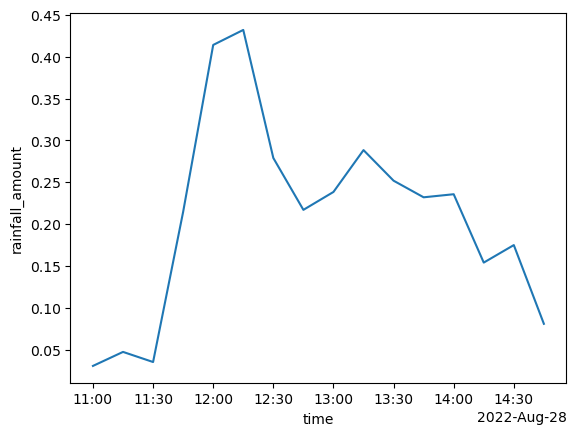

In [15]:
ds_cmls.rainfall_amount.sel(time = slice(start, end)).mean(dim = 'cml_id').plot()

In [16]:
ds_gauges = ds_gauges.sel(time = slice(start, end))
ds_rad = ds_rad.sel(time = slice(start, end)) 
ds_cmls = ds_cmls.sel(time = slice(start, end)) 
rad_along = rad_along.sel(time = slice(start, end)) 

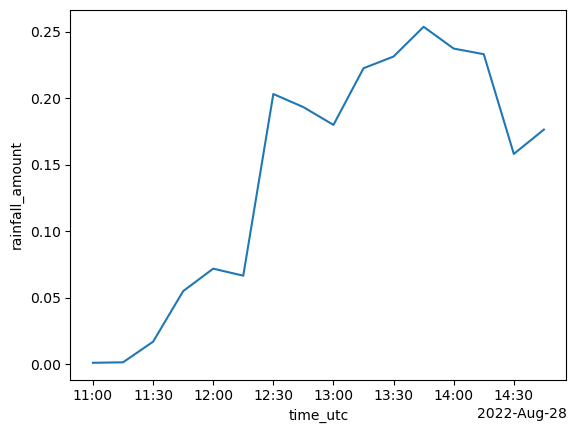

In [17]:
ds_gauges.rainfall_amount.sel(time = slice(start, end)).mean(dim = 'id').plot()

In [18]:
ds_cmls['rainfall_amount'] = xr.where(
    np.abs(ds_cmls.rainfall_amount - ds_cmls.rainfall_radar) > 10,
    np.nan,
    ds_cmls.rainfall_amount
)

In [19]:
train_test_split = 0.4
np.random.seed(0)

# Do split
total_id = np.arange(ds_gauges.id.size)
np.random.shuffle(total_id)
train_id = total_id[:int(train_test_split*total_id.size)]
test_id = np.array([i for i in total_id if i not in train_id])
ds_gauges_test = ds_gauges.isel(id = test_id).copy()
ds_gauges = ds_gauges.isel(id = train_id).copy()

# interpolate rain gauges

In [20]:
def transform_cml_coordinates(ds_cmls, ds_grid, t_target, t_back, t_forw, nugget_time, motion_field):
    # Rain gauge transformed coordinates 
    coords = np.zeros([t_back+t_forw+1, ds_cmls.x.size, 6])
    
    # Set target coordinates
    coords[t_back, :, 0] = ds_cmls.y.data
    coords[t_back, :, 1] = ds_cmls.x.data
    coords[t_back, :, 2] = ds_cmls.site_0_y.data
    coords[t_back, :, 3] = ds_cmls.site_0_x.data
    coords[t_back, :, 4] = ds_cmls.site_1_y.data
    coords[t_back, :, 5] = ds_cmls.site_1_x.data
    
    # Grid data for fast access
    x_grid = ds_grid.x_grid.data
    y_grid = ds_grid.y_grid.data
    
    # Time step duration in seconds
    dt = 1000  # size of each cell [m]

    # Motion field to u,v
    u, v = motion_field[0], motion_field[1]  # Mot

    # Backtrack the rain gauge locations
    for t in reversed(range(1, t_back+1)):  
        y0 = coords[t, :, 0]
        x0 = coords[t, :, 1]
        
        # Array for storing index of observations
        yx_index = np.zeros([x0.size, 2]).astype(int)
    
        # Distances for all obs to all gridpoints 
        distances = np.sqrt((x0.reshape(-1, 1, 1) - x_grid)**2 + (y0.reshape(-1, 1, 1) - y_grid)**2)
    
        # Get grid location
        for gauge_i in range(x0.size):
            index = np.argmin(distances[gauge_i])
            yx_index[gauge_i, 0], yx_index[gauge_i, 1] = np.unravel_index(index, x_grid.shape)
    
        dx = u[yx_index[:, 0], yx_index[:, 1]] * dt  # Displacement in x-direction
        dy = v[yx_index[:, 0], yx_index[:, 1]] * dt  # Displacement in y-direction
        
        coords[t-1, :, 0] = coords[t, :, 0] + dy 
        coords[t-1, :, 1] = coords[t, :, 1] + dx  
        coords[t-1, :, 2] = coords[t, :, 2] + dy 
        coords[t-1, :, 3] = coords[t, :, 3] + dx  
        coords[t-1, :, 4] = coords[t, :, 4] + dy 
        coords[t-1, :, 5] = coords[t, :, 5] + dx  
        
    
    # Shift forward the rain gauge coordinates
    for t in range(t_back, t_back+t_forw): 
        y0 = coords[t, :, 0]
        x0 = coords[t, :, 1]
        
        # Array for storing index of observations
        yx_index = np.zeros([x0.size, 2]).astype(int)
    
        # Distances for all obs to all gridpoints (fast ish)
        distances = np.sqrt((x0.reshape(-1, 1, 1) - x_grid)**2 + (y0.reshape(-1, 1, 1) - y_grid)**2)
    
        # Get grid location
        for gauge_i in range(x0.size):
            index = np.argmin(distances[gauge_i])
            yx_index[gauge_i, 0], yx_index[gauge_i, 1] = np.unravel_index(index, x_grid.shape)
    
        dx = u[yx_index[:, 0], yx_index[:, 1]] * dt  # Displacement in x-direction
        dy = v[yx_index[:, 0], yx_index[:, 1]] * dt  # Displacement in y-direction
        
        coords[t+1, :, 0] = coords[t, :, 0] - dy  # Adjust latitude
        coords[t+1, :, 1] = coords[t, :, 1] - dx  # Adjust longitude
        coords[t+1, :, 2] = coords[t, :, 2] - dy 
        coords[t+1, :, 3] = coords[t, :, 3] - dx  
        coords[t+1, :, 4] = coords[t, :, 4] - dy 
        coords[t+1, :, 5] = coords[t, :, 5] - dx  
    
    # Apply coordinate transform to time steps
    ds_cmls_transformed = []
    for t, time  in enumerate(ds_cmls.isel(time = slice(t_target - t_back, t_target + t_forw +1)).time.data):
        ds_cmls_t = ds_cmls.sel(time = time).copy()
        ds_cmls_t = ds_cmls_t.drop_vars('time')
    
        # Move coordinates
        ds_cmls_t.coords['y'] = ('cml_id', coords[t, :, 0])
        ds_cmls_t.coords['x'] = ('cml_id', coords[t, :, 1])
        ds_cmls_t.coords['site_0_y'] = ('cml_id', coords[t, :, 2])
        ds_cmls_t.coords['site_0_x'] = ('cml_id', coords[t, :, 3])
        ds_cmls_t.coords['site_1_y'] = ('cml_id', coords[t, :, 4])
        ds_cmls_t.coords['site_1_x'] = ('cml_id', coords[t, :, 5])
    
        # rename stations to include timesteps
        ds_cmls_t.coords['cml_id'] = ds_cmls_t.cml_id.data + '_t'+str(t)
    
        # Store
        ds_cmls_transformed.append(ds_cmls_t)    
    
    # Merge to one dataset
    ds_cmls_transformed = xr.concat(ds_cmls_transformed, dim='cml_id')

    # Set timestamp to t_target
    timestamp = ds_cmls.isel(time = t_target).time.data
    ds_cmls_transformed = ds_cmls_transformed.assign_coords({'time':  timestamp})
    ds_cmls_transformed = ds_cmls_transformed.expand_dims('time')

    # Compute observation uncertainties for timesteps
    sigma = []
    for t, time  in enumerate(ds_cmls.isel(time = slice(t_target - t_back, t_target + t_forw +1)).time.data):
        nugg_add = nugget_time*np.abs(t_back - t)**1
        for id in range(ds_cmls.cml_id.size):
            sigma.append(float(nugg_add))
            
    ds_cmls_transformed['sigma'] = (('time', 'cml_id'), np.array([sigma]))
    return ds_cmls_transformed

In [21]:
def transform_gauge_coordinates(ds_gauges, ds_grid, t_target, t_back, t_forw, nugget_time, motion_field):
    # Rain gauge transformed coordinates 
    coords = np.zeros([t_back+t_forw+1, ds_gauges.x.size, 2])
    
    # Set target coordinates
    coords[t_back, :, 0] = ds_gauges.y
    coords[t_back, :, 1] = ds_gauges.x
    
    # Grid data for fast access
    x_grid = ds_grid.x_grid.data
    y_grid = ds_grid.y_grid.data
    
    # Time step duration in seconds
    dt = 1000  # size of each cell [m]

    # Motion field to u,v
    u, v = motion_field[0], motion_field[1]  # Mot

    # Backtrack the rain gauge locations
    for t in reversed(range(1, t_back+1)):  
        y0 = coords[t, :, 0]
        x0 = coords[t, :, 1]
        
        # Array for storing index of observations
        yx_index = np.zeros([x0.size, 2]).astype(int)
    
        # Distances for all obs to all gridpoints 
        distances = np.sqrt((x0.reshape(-1, 1, 1) - x_grid)**2 + (y0.reshape(-1, 1, 1) - y_grid)**2)
    
        # Get grid location
        for gauge_i in range(x0.size):
            index = np.argmin(distances[gauge_i])
            yx_index[gauge_i, 0], yx_index[gauge_i, 1] = np.unravel_index(index, x_grid.shape)
    
        dx = u[yx_index[:, 0], yx_index[:, 1]] * dt  # Displacement in x-direction
        dy = v[yx_index[:, 0], yx_index[:, 1]] * dt  # Displacement in y-direction
        
        coords[t-1, :, 0] = coords[t, :, 0] + dy  # Adjust latitude
        coords[t-1, :, 1] = coords[t, :, 1] + dx  # Adjust longitude
    
    # Shift forward the rain gauge coordinates
    for t in range(t_back, t_back+t_forw): 
        y0 = coords[t, :, 0]
        x0 = coords[t, :, 1]
        
        # Array for storing index of observations
        yx_index = np.zeros([x0.size, 2]).astype(int)
    
        # Distances for all obs to all gridpoints (fast ish)
        distances = np.sqrt((x0.reshape(-1, 1, 1) - x_grid)**2 + (y0.reshape(-1, 1, 1) - y_grid)**2)
    
        # Get grid location
        for gauge_i in range(x0.size):
            index = np.argmin(distances[gauge_i])
            yx_index[gauge_i, 0], yx_index[gauge_i, 1] = np.unravel_index(index, x_grid.shape)
    
        dx = u[yx_index[:, 0], yx_index[:, 1]] * dt  # Displacement in x-direction
        dy = v[yx_index[:, 0], yx_index[:, 1]] * dt  # Displacement in y-direction
        
        coords[t+1, :, 0] = coords[t, :, 0] - dy  # Adjust latitude
        coords[t+1, :, 1] = coords[t, :, 1] - dx  # Adjust longitude

    # Apply coordinate transform to time steps
    ds_gauges_transformed = []
    for t, time  in enumerate(ds_gauges.isel(time = slice(t_target - t_back, t_target + t_forw +1)).time.data):
        ds_gauges_t = ds_gauges.sel(time = time).copy()
        ds_gauges_t = ds_gauges_t.drop_vars('time')
    
        # Move coordinates
        ds_gauges_t.coords['y'] = ('id', coords[t, :, 0])
        ds_gauges_t.coords['x'] = ('id', coords[t, :, 1])
    
        # rename stations to include timesteps
        ds_gauges_t.coords['id'] = ds_gauges_t.id.data + '_t'+str(t)
    
        # Store
        ds_gauges_transformed.append(ds_gauges_t)    
    
    # Merge to one dataset
    ds_gauges_transformed = xr.concat(ds_gauges_transformed, dim='id')

    # Set timestamp to t_target
    timestamp = ds_gauges.isel(time = t_target).time.data
    ds_gauges_transformed = ds_gauges_transformed.assign_coords({'time':  timestamp})
    ds_gauges_transformed = ds_gauges_transformed.expand_dims('time')

    # Compute observation uncertainties for timesteps
    sigma = []
    for t, time  in enumerate(ds_gauges.isel(time = slice(t_target - t_back, t_target + t_forw +1)).time.data):
        nugg_add = nugget_time*np.abs(t_back - t)
        for id in range(ds_gauges.id.size):
            sigma.append(float(nugg_add))
            
    ds_gauges_transformed['sigma'] = (('time', 'id'), np.array([sigma]))
    return ds_gauges_transformed

In [22]:
# Function 
variogram_parameters = {"sill": 1, "range": 10000, "nugget": 0.2}
variogram_parameters_cml = variogram_parameters

nugget_time = 5  # variance added for observations at different time steps
nugget_time_cml = nugget_time
nnear = 12

# Timesteps to use for advection transformation
t_back = 2
t_forw = 2 

# Timesteps to use for motion field
t_back_motion = 3 #
t_forw_motion = 3 #

In [23]:
merger = mergeplg.interpolate.InterpolateOrdinaryKriging(
    ds_grid=ds_rad, # can be replaced with a custom grid
    ds_gauges=ds_gauges,
    full_line=False,
    variogram_parameters=variogram_parameters,
    nnear=nnear,
)
rainfall = []
for time in ds_gauges.time.data:
    rainfall.append(
        merger(
            da_gauges=ds_gauges.rainfall_amount.sel(time=time),
        )
    )
ds_rad["rainfall_gaugeinterpolate"] = xr.concat(rainfall, dim="time")

In [24]:
merger = mergeplg.interpolate.InterpolateOrdinaryKriging(
    ds_grid=ds_rad, # can be replaced with a custom grid
    ds_cmls=ds_cmls,
    full_line=False,
    variogram_parameters=variogram_parameters_cml,
    nnear=nnear,
)
rainfall = []
for time in ds_gauges.time.data:
    rainfall.append(
        merger(
            da_cmls=ds_cmls.rainfall_amount.sel(time=time),
        )
    )
ds_rad["rainfall_cmlinterpolate"] = xr.concat(rainfall, dim="time")

In [25]:
merger = mergeplg.merge.MergeDifferenceOrdinaryKriging(
    ds_rad=ds_rad, # can be replaced with a custom grid
    ds_gauges=ds_gauges,
    full_line=False,
    variogram_parameters=variogram_parameters,
    nnear=nnear,
)
rainfall = []
for time in ds_gauges.time.data:
    rainfall.append(
        merger(
            da_rad=ds_rad.rainfall_amount.sel(time = time),
            da_gauges=ds_gauges.rainfall_amount.sel(time=time),
        )
    )
ds_rad["rainfall_gaugemerge"] = xr.concat(rainfall, dim="time")

In [26]:
merger = mergeplg.merge.MergeDifferenceOrdinaryKriging(
    ds_rad=ds_rad, # can be replaced with a custom grid
    ds_cmls=ds_cmls,
    full_line=False,
    variogram_parameters=variogram_parameters_cml,
    nnear=nnear,
)
rainfall = []
for time in ds_gauges.time.data:
    rainfall.append(
        merger(
            da_rad=ds_rad.rainfall_amount.sel(time = time),
            da_cmls=ds_cmls.rainfall_amount.sel(time=time),
        )
    )
ds_rad["rainfall_cmlmerge"] = xr.concat(rainfall, dim="time")

In [27]:
rainfall = []
for t, time_target in enumerate(ds_cmls.time[t_back_motion:-t_forw_motion]):
    # Time indice for interpolation
    t_target = t + t_back_motion 

    # Start and end timestamps
    time_start_motion = ds_gauges.isel(time = t_target - t_back_motion).time 
    time_end_motion = ds_gauges.isel(time = t_target + t_forw_motion).time

    # Estimate motion field
    motion_field = dense_lucaskanade(
        ds_rad.rainfall_amount.sel(time = slice(time_start_motion, time_end_motion))
    )

    # Start and end timesteps for interpolation
    time_start = ds_gauges.isel(time = t_target - t_back).time 
    time_end = ds_gauges.isel(time = t_target + t_forw).time 

    # Compute transformed coordinates
    ds_gauges_transformed = transform_gauge_coordinates(ds_gauges, ds_rad, t_target, t_back, t_forw, nugget_time, motion_field)
    
    interpolator = mergeplg.interpolate.InterpolateOrdinaryKriging(
        ds_grid=ds_rad, # can be replaced with a custom grid
        ds_gauges=ds_gauges_transformed,
        full_line=False,
        variogram_parameters=variogram_parameters,
        nnear=nnear,
    )
    
    rainfall.append(
        interpolator(
            da_gauges=ds_gauges_transformed.rainfall_amount.isel(time=0),
            da_gauges_sigma=ds_gauges_transformed.sigma.isel(time=0)
        )
    )

ds_rad["rainfall_gaugeinterpolateadvection"] = xr.concat(rainfall, dim="time").reindex(time=ds_rad["time"])

In [28]:
rainfall = []
for t, time_target in enumerate(ds_cmls.time[t_back_motion:-t_forw_motion]):
    # Time indice for interpolation
    t_target = t + t_back_motion 

    # Start and end timestamps
    time_start_motion = ds_gauges.isel(time = t_target - t_back_motion).time 
    time_end_motion = ds_gauges.isel(time = t_target + t_forw_motion).time

    # Estimate motion field
    motion_field = dense_lucaskanade(
        ds_rad.rainfall_amount.sel(time = slice(time_start_motion, time_end_motion))
    )

    # Start and end timesteps for interpolation
    time_start = ds_gauges.isel(time = t_target - t_back).time 
    time_end = ds_gauges.isel(time = t_target + t_forw).time 

    # Compute transformed coordinates
    ds_cmls_transformed = transform_cml_coordinates(ds_cmls, ds_rad, t_target, t_back, t_forw, nugget_time_cml, motion_field)
    
    interpolator = mergeplg.interpolate.InterpolateOrdinaryKriging(
        ds_grid=ds_rad, # can be replaced with a custom grid
        ds_cmls=ds_cmls_transformed,
        full_line=False,
        variogram_parameters=variogram_parameters_cml,
        nnear=nnear,
    )
    
    rainfall.append(
        interpolator(
            da_cmls=ds_cmls_transformed.rainfall_amount.isel(time=0),
            da_cmls_sigma=ds_cmls_transformed.sigma.isel(time=0)
        )
    )

ds_rad["rainfall_cmlinterpolateadvection"] = xr.concat(rainfall, dim="time").reindex(time=ds_rad["time"])

In [29]:
rainfall = []
for t, time_target in enumerate(ds_cmls.time[t_back_motion:-t_forw_motion]):
    # Time indice for interpolation
    t_target = t + t_back_motion 

    # Start and end timestamps
    time_start_motion = ds_gauges.isel(time = t_target - t_back_motion).time 
    time_end_motion = ds_gauges.isel(time = t_target + t_forw_motion).time

    # Estimate motion field
    motion_field = dense_lucaskanade(
        ds_rad.rainfall_amount.sel(time = slice(time_start_motion, time_end_motion))
    )

    # Start and end timesteps for interpolation
    time_start = ds_gauges.isel(time = t_target - t_back).time 
    time_end = ds_gauges.isel(time = t_target + t_forw).time 

    # Compute transformed coordinates
    ds_gauges_transformed = transform_gauge_coordinates(ds_gauges, ds_rad, t_target, t_back, t_forw, nugget_time, motion_field)

    merger = mergeplg.merge.MergeDifferenceOrdinaryKriging(
        ds_rad=ds_rad.rainfall_amount.sel(time = time_target), # can be replaced with a custom grid
        ds_gauges=ds_gauges_transformed,
        full_line=False,
        variogram_parameters=variogram_parameters,
        nnear=nnear,
    )
    
    rainfall.append(
        merger(
            da_rad=ds_rad.rainfall_amount.sel(time = time_target),
            da_gauges=ds_gauges_transformed.rainfall_amount.isel(time=0),
            da_gauges_sigma=ds_gauges_transformed.sigma.isel(time=0)
        )
    )

ds_rad["rainfall_gaugemergeadvection"] = xr.concat(rainfall, dim="time").reindex(time=ds_rad["time"])

In [30]:
rainfall = []
for t, time_target in enumerate(ds_cmls.time[t_back_motion:-t_forw_motion]):
    # Time indice for interpolation
    t_target = t + t_back_motion 

    # Start and end timestamps
    time_start_motion = ds_gauges.isel(time = t_target - t_back_motion).time 
    time_end_motion = ds_gauges.isel(time = t_target + t_forw_motion).time

    # Estimate motion field
    motion_field = dense_lucaskanade(
        ds_rad.rainfall_amount.sel(time = slice(time_start_motion, time_end_motion))
    )

    # Start and end timesteps for interpolation
    time_start = ds_gauges.isel(time = t_target - t_back).time 
    time_end = ds_gauges.isel(time = t_target + t_forw).time 

    # Compute transformed coordinates
    ds_cmls_transformed = transform_cml_coordinates(ds_cmls, ds_rad, t_target, t_back, t_forw, nugget_time_cml, motion_field)

    merger = mergeplg.merge.MergeDifferenceOrdinaryKriging(
        ds_rad=ds_rad.rainfall_amount.sel(time = time_target), # can be replaced with a custom grid
        ds_cmls=ds_cmls_transformed,
        full_line=False,
        variogram_parameters=variogram_parameters_cml,
        nnear=nnear,
    )
    
    rainfall.append(
        merger(
            da_rad=ds_rad.rainfall_amount.sel(time = time_target),
            da_cmls=ds_cmls_transformed.rainfall_amount.isel(time=0),
            da_cmls_sigma=ds_cmls_transformed.sigma.isel(time=0)
        )
    )

ds_rad["rainfall_cmlmergeadvection"] = xr.concat(rainfall, dim="time").reindex(time=ds_rad["time"])

In [31]:
rainfall = []
for t, time_target in enumerate(ds_cmls.time[t_back_motion:-t_forw_motion]):
    # Time indice for interpolation
    t_target = t + t_back_motion 

    # Start and end timestamps
    time_start_motion = ds_gauges.isel(time = t_target - t_back_motion).time 
    time_end_motion = ds_gauges.isel(time = t_target + t_forw_motion).time

    # Estimate motion field
    motion_field = dense_lucaskanade(
        ds_rad.rainfall_amount.sel(time = slice(time_start_motion, time_end_motion))
    )

    # Start and end timesteps for interpolation
    time_start = ds_gauges.isel(time = t_target - t_back).time 
    time_end = ds_gauges.isel(time = t_target + t_forw).time 

    # Compute transformed coordinates
    ds_cmls_transformed = transform_cml_coordinates(ds_cmls, ds_rad, t_target, t_back, t_forw, nugget_time_cml, motion_field)
    ds_gauges_transformed = transform_gauge_coordinates(ds_gauges, ds_rad, t_target, t_back, t_forw, nugget_time, motion_field)

    merger = mergeplg.merge.MergeDifferenceOrdinaryKriging(
        ds_rad=ds_rad.rainfall_amount.sel(time = time_target), # can be replaced with a custom grid
        ds_cmls=ds_cmls_transformed,
        ds_gauges=ds_gauges_transformed,
        full_line=False,
        variogram_parameters=variogram_parameters_cml,
        nnear=nnear,
    )
    
    rainfall.append(
        merger(
            da_rad=ds_rad.rainfall_amount.sel(time = time_target),
            da_gauges=ds_gauges_transformed.rainfall_amount.isel(time=0),
            da_gauges_sigma=ds_gauges_transformed.sigma.isel(time=0),
            da_cmls=ds_cmls_transformed.rainfall_amount.isel(time=0),
            da_cmls_sigma=ds_cmls_transformed.sigma.isel(time=0)
        )
    )

ds_rad["rainfall_cmlgaugemergeadvection"] = xr.concat(rainfall, dim="time").reindex(time=ds_rad["time"])

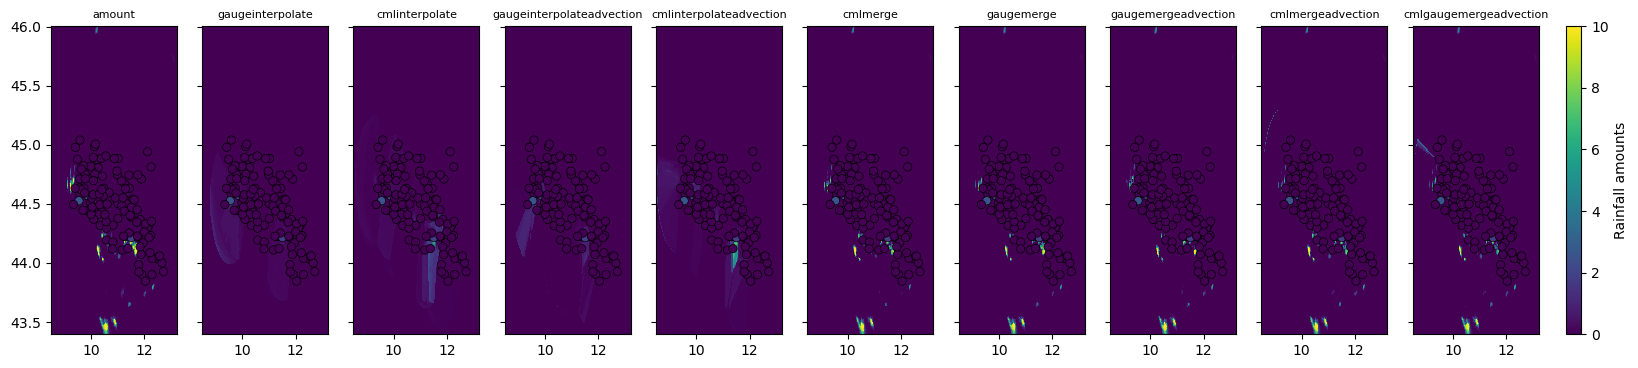

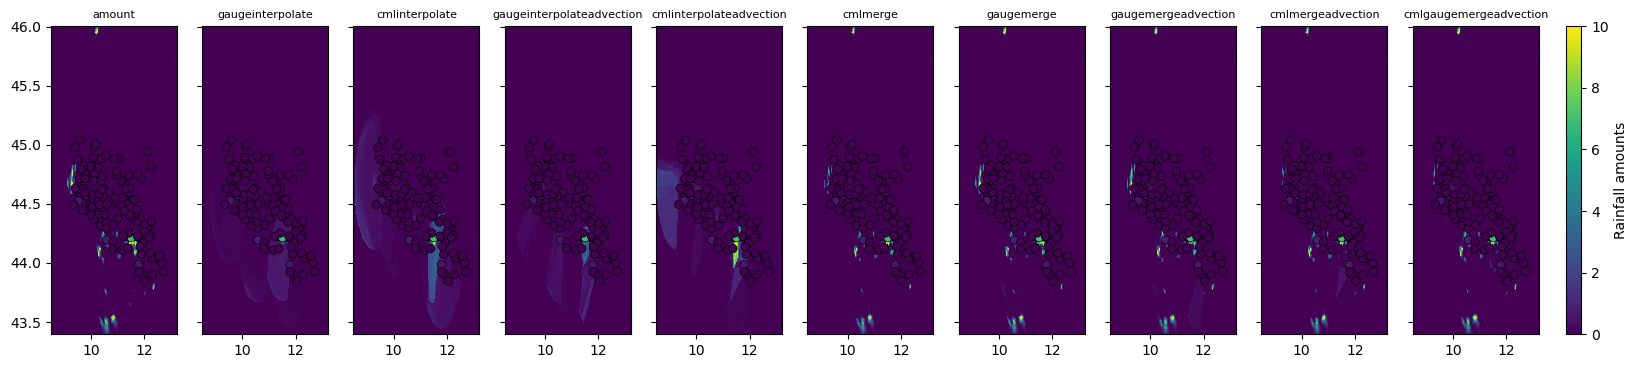

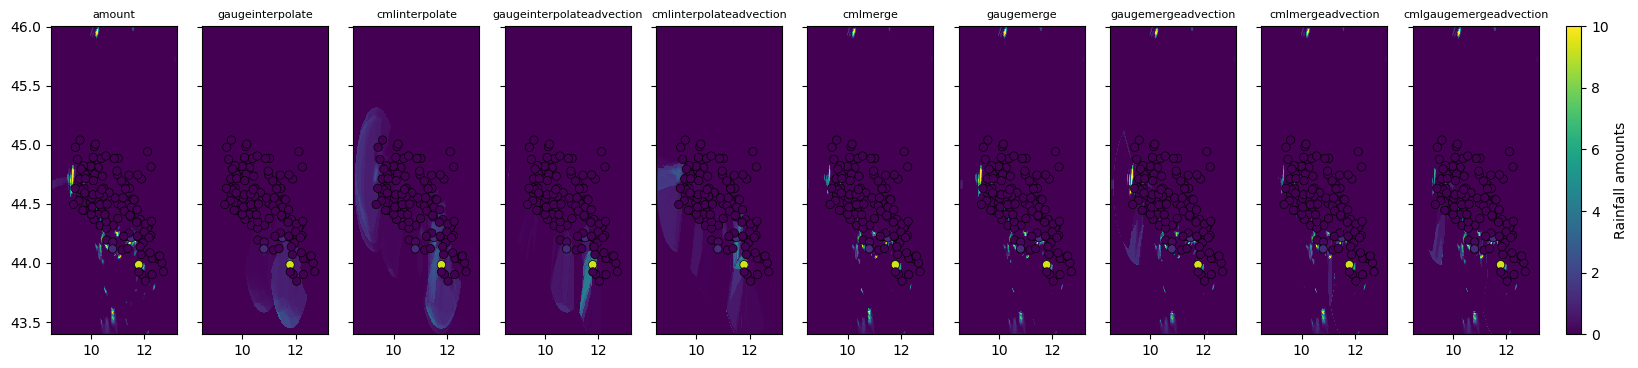

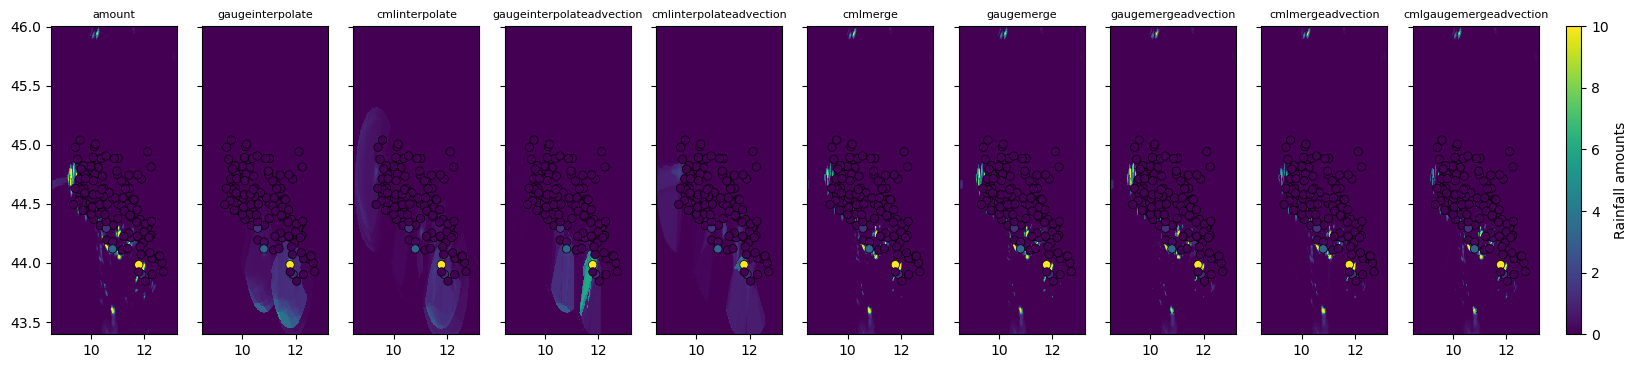

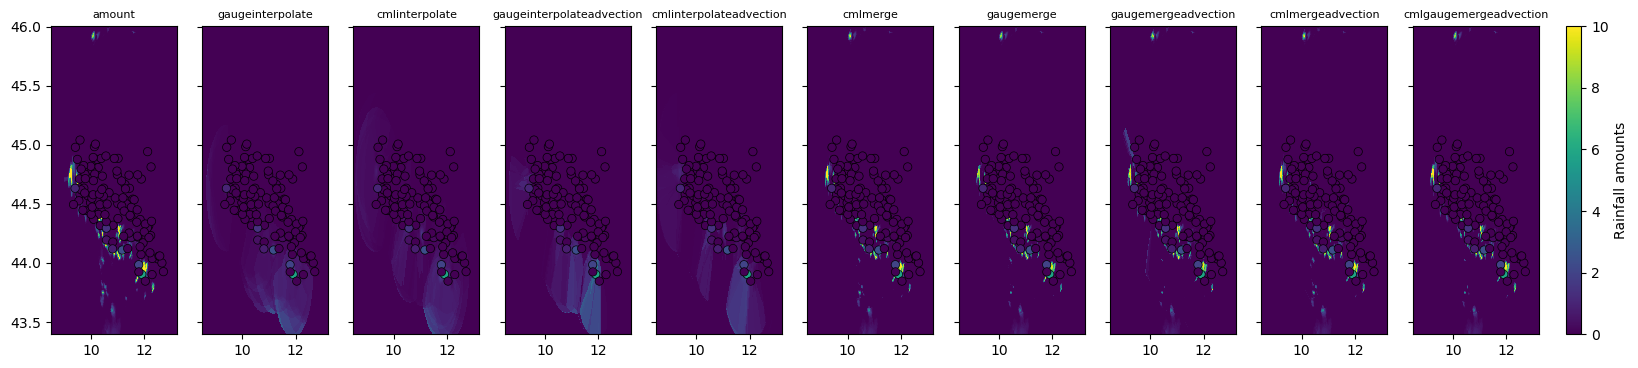

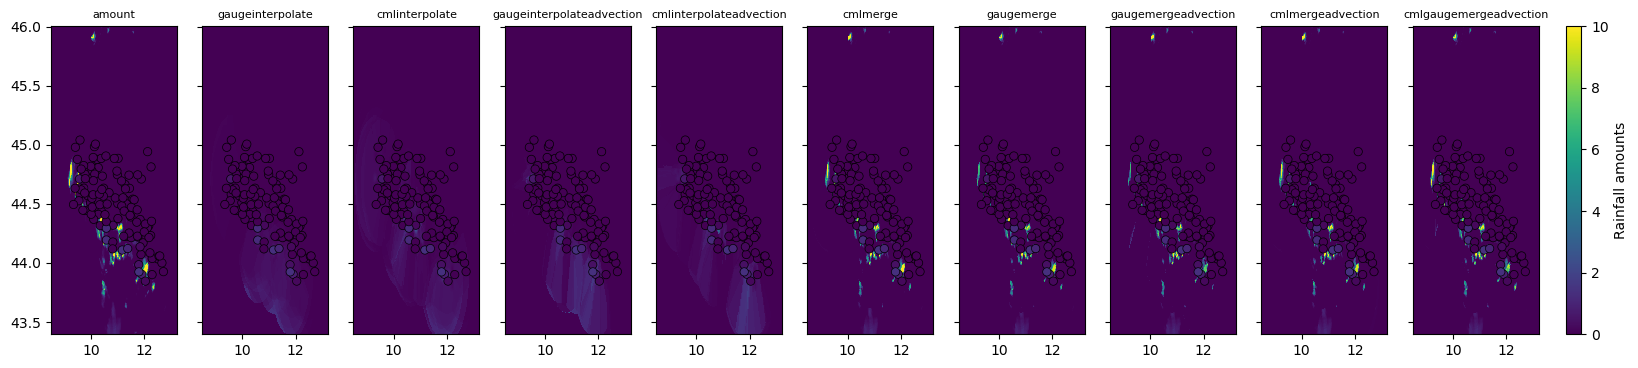

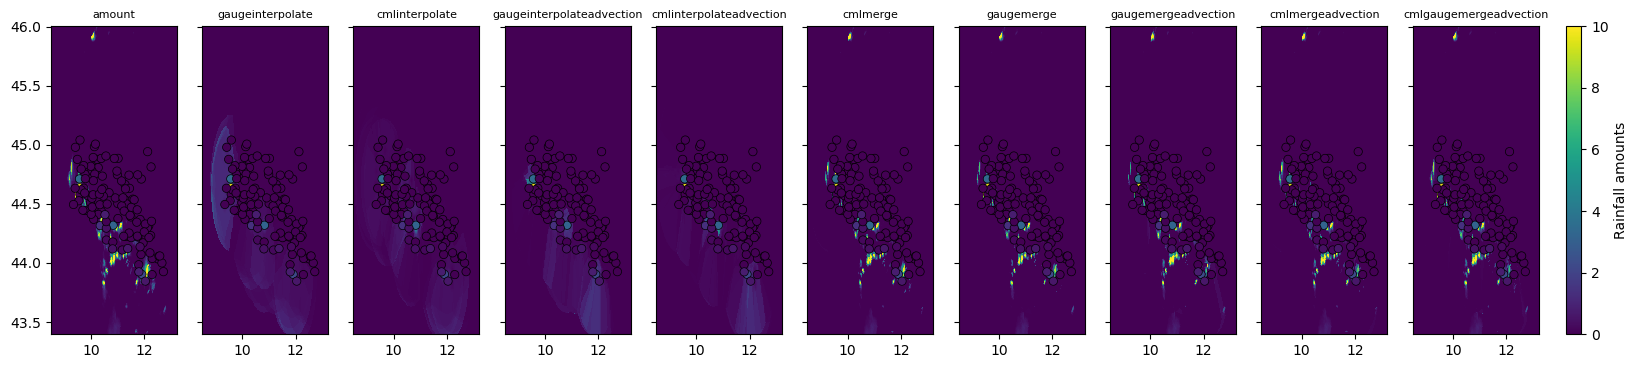

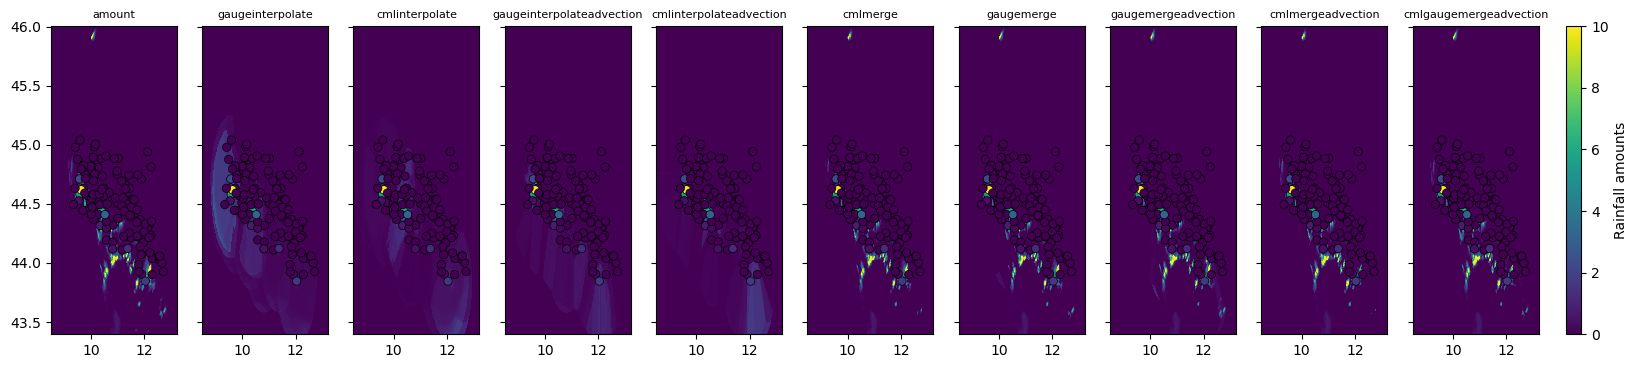

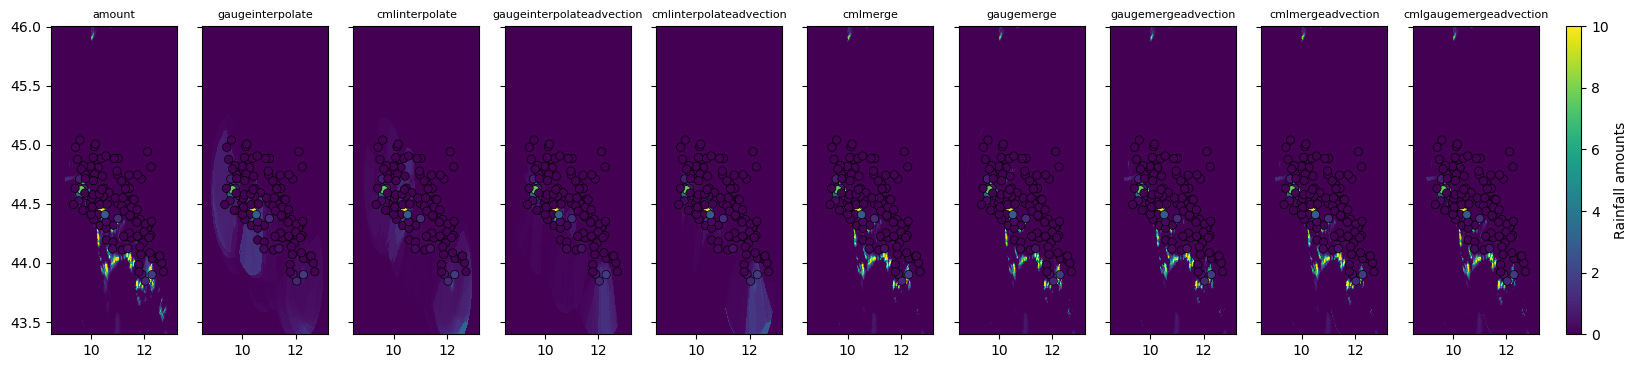

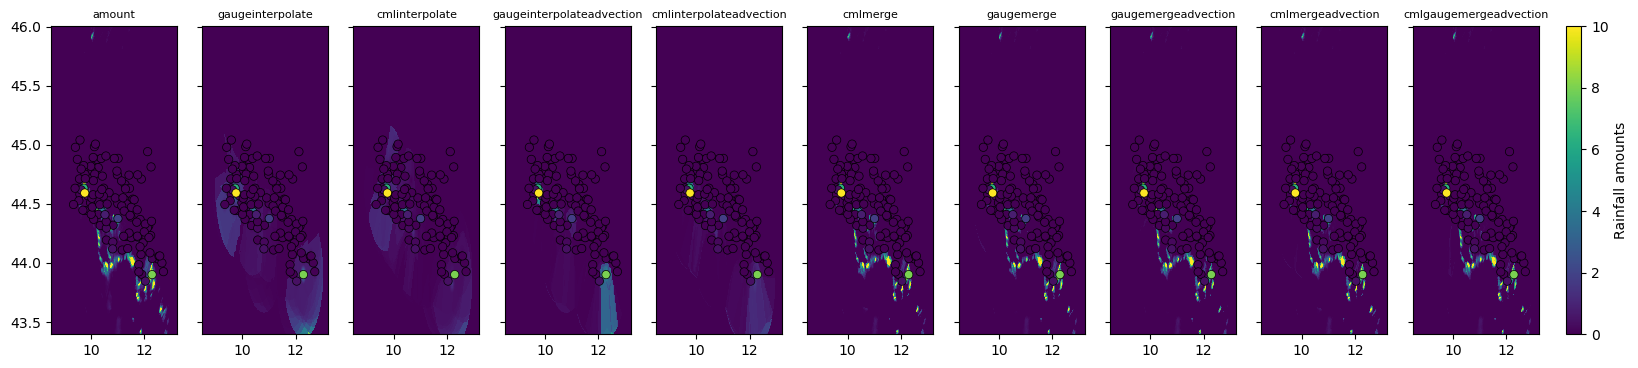

In [32]:
vmax = 10  # max color
cmap_rain = "viridis"

# Rainfall fields to plot
rainfall_fields = [
    "rainfall_amount",
    "rainfall_gaugeinterpolate",
    "rainfall_cmlinterpolate",
    "rainfall_gaugeinterpolateadvection",
    "rainfall_cmlinterpolateadvection",
    "rainfall_cmlmerge",
    "rainfall_gaugemerge",
    "rainfall_gaugemergeadvection",
    "rainfall_cmlmergeadvection",
    "rainfall_cmlgaugemergeadvection",
]

for time in ds_cmls.time[t_back_motion:-t_forw_motion]:
    fig, ax = plt.subplots(1, len(rainfall_fields), figsize=(24, 4), sharey=True)
    for i, rainfall_field in enumerate(rainfall_fields):
        # Plot rainfall field
        im = ax[i].pcolormesh(
            ds_rad.lon,
            ds_rad.lat,
            ds_rad[rainfall_field].sel(time=time),
            vmin=0,
            vmax=vmax,
            cmap=cmap_rain,
        )
        ax[i].scatter(
            ds_gauges.lon, 
            ds_gauges.lat, 
            c=ds_gauges.sel(time=time).rainfall_amount, 
            vmin=0, 
            vmax=vmax,
            edgecolors='black',  # Add a black outline
            linewidth=0.5        # Adjust the thickness of the outline
        )
        

        ax[i].set_title(rainfall_field.split("_")[1], fontdict={'fontsize': 8})

    clb = fig.colorbar(im, ax=ax, location="right", anchor=(-0.25, 1.0))
    clb.ax.set_ylabel("Rainfall amounts")
    plt.show()

    

In [33]:
get_grid_at_points = plg.spatial.GridAtPoints(
    da_gridded_data=ds_rad,
    da_point_data=ds_gauges_test,
    nnear=1,
    stat="best",
)

# 
times_evaluate = ds_gauges_test.time[t_back_motion:-t_forw_motion]
ds_gauges_test_t = ds_gauges_test.sel(time = times_evaluate)

ds_gauges_test_t['rainfall_radar'] = get_grid_at_points(
    da_gridded_data=ds_rad.rainfall_amount.sel(time = times_evaluate),
    da_point_data=ds_gauges_test.rainfall_amount,
)

ds_gauges_test_t['rainfall_gaugeinterpolate']  = get_grid_at_points(
    da_gridded_data=ds_rad.rainfall_gaugeinterpolate.sel(time = times_evaluate),
    da_point_data=ds_gauges_test.rainfall_amount,
)
ds_gauges_test_t['rainfall_cmlinterpolate']  = get_grid_at_points(
    da_gridded_data=ds_rad.rainfall_cmlinterpolate.sel(time = times_evaluate),
    da_point_data=ds_gauges_test.rainfall_amount,
)

ds_gauges_test_t['rainfall_gaugeinterpolateadvection']  = get_grid_at_points(
    da_gridded_data=ds_rad.rainfall_gaugeinterpolateadvection.sel(time = times_evaluate),
    da_point_data=ds_gauges_test.rainfall_amount,
)
ds_gauges_test_t['rainfall_cmlinterpolateadvection']  = get_grid_at_points(
    da_gridded_data=ds_rad.rainfall_cmlinterpolateadvection.sel(time = times_evaluate),
    da_point_data=ds_gauges_test.rainfall_amount,
)

ds_gauges_test_t['rainfall_gaugemerge']  = get_grid_at_points(
    da_gridded_data=ds_rad.rainfall_gaugemerge.sel(time = times_evaluate),
    da_point_data=ds_gauges_test.rainfall_amount,
)
ds_gauges_test_t['rainfall_cmlmerge']  = get_grid_at_points(
    da_gridded_data=ds_rad.rainfall_cmlmerge.sel(time = times_evaluate),
    da_point_data=ds_gauges_test.rainfall_amount,
)

ds_gauges_test_t['rainfall_gaugemergeadvection']  = get_grid_at_points(
    da_gridded_data=ds_rad.rainfall_gaugemergeadvection.sel(time = times_evaluate),
    da_point_data=ds_gauges_test.rainfall_amount,
)
ds_gauges_test_t['rainfall_cmlmergeadvection']  = get_grid_at_points(
    da_gridded_data=ds_rad.rainfall_cmlmergeadvection.sel(time = times_evaluate),
    da_point_data=ds_gauges_test.rainfall_amount,
)
ds_gauges_test_t['rainfall_cmlgaugemergeadvection']  = get_grid_at_points(
    da_gridded_data=ds_rad.rainfall_cmlgaugemergeadvection.sel(time = times_evaluate),
    da_point_data=ds_gauges_test.rainfall_amount,
)



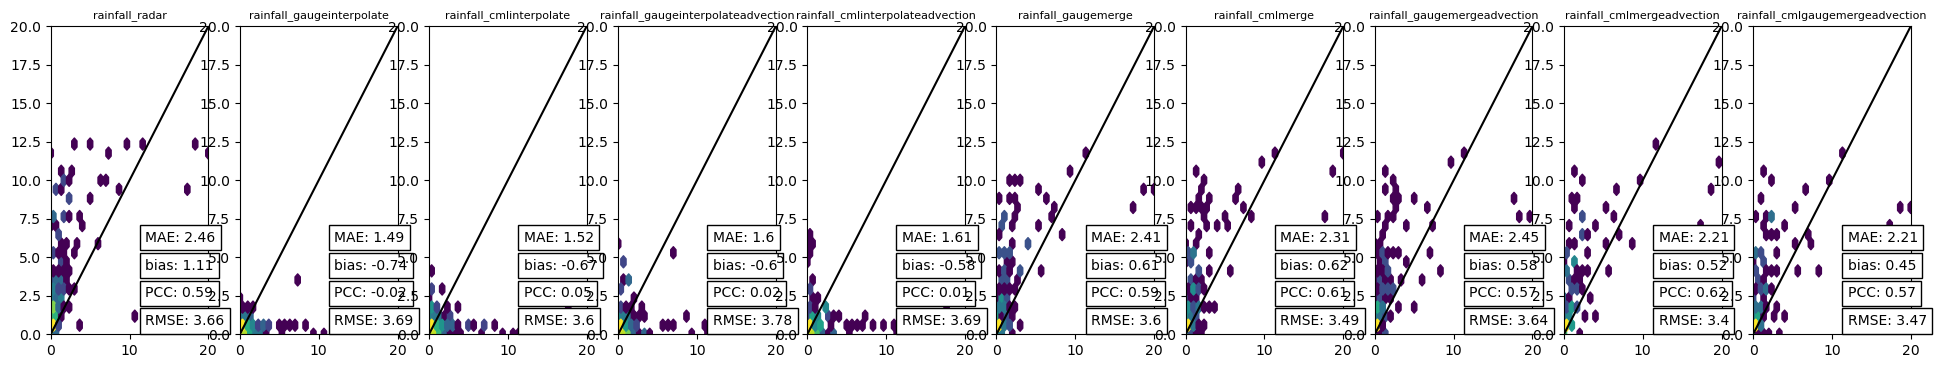

In [34]:
max_ext = 20
extent = [0, max_ext, 0, max_ext]
gridsize = 30

pred_models = [
    ds_gauges_test_t.rainfall_radar,
    ds_gauges_test_t.rainfall_gaugeinterpolate,
    ds_gauges_test_t.rainfall_cmlinterpolate,

    ds_gauges_test_t.rainfall_gaugeinterpolateadvection,
    ds_gauges_test_t.rainfall_cmlinterpolateadvection,

    ds_gauges_test_t.rainfall_gaugemerge,
    ds_gauges_test_t.rainfall_cmlmerge,

    ds_gauges_test_t.rainfall_gaugemergeadvection,
    ds_gauges_test_t.rainfall_cmlmergeadvection,

    ds_gauges_test_t.rainfall_cmlgaugemergeadvection,

]
fig, ax = plt.subplots(1, len(pred_models), figsize=(24, 4))
ground = ds_gauges_test_t.rainfall_amount.data.ravel()
for i in range(len(pred_models)):
    tar = pred_models[i].data.ravel()
    keep = (ground > 0) & (tar > 0)

    ax[i].hexbin(
        ground[keep], tar[keep], mincnt=1, extent=extent, gridsize=gridsize, bins="log"
    )
    
    ax[i].text(
        0.6,
        0.03,
        "RMSE: " + str(round(np.sqrt(np.mean((ground[keep] - tar[keep]) ** 2)), 2)),
        bbox={"facecolor": "white", "edgecolor": "black"},
        transform=ax[i].transAxes,
    )
    ax[i].text(
        0.6,
        0.12,
        "PCC: " + str(round(np.corrcoef(ground[keep], tar[keep])[0, 1], 2)),
        bbox={"facecolor": "white", "edgecolor": "black"},
        transform=ax[i].transAxes,
    )
    ax[i].text(
        0.6,
        0.21,
        "bias: "
        + str(round(np.mean(tar[keep] - ground[keep]) / np.mean(ground[keep]), 2)),
        bbox={"facecolor": "white", "edgecolor": "black"},
        transform=ax[i].transAxes,
    )
    ax[i].text(
        0.6,
        0.3,
        "MAE: " + str(round(np.mean(np.abs(tar[keep] - ground[keep])), 2)),
        bbox={"facecolor": "white", "edgecolor": "black"},
        transform=ax[i].transAxes,
    )
    ax[i].plot([0, extent[1]], [0, extent[1]], "k")

    ax[i].set_title(pred_models[i].name, fontdict={'fontsize': 8})
    ax[i].set_xlim(0, extent[1])
    ax[i].set_ylim(0, extent[1])

    